# Telecom X - Predicción de Cancelación de Clientes (Churn)

## Introducción

En este proyecto desarrollaré modelos de Machine Learning para predecir qué clientes tienen mayor probabilidad de cancelar sus servicios en Telecom X.

El objetivo es construir un pipeline de análisis que me permita preparar los datos, entrenar modelos de clasificación y evaluar su rendimiento. A partir de estos resultados, buscaré identificar qué variables influyen más en la cancelación de clientes y generar insights que puedan ayudar a la empresa a anticiparse a este problema y mejorar sus estrategias de retención.

In [4]:
import pandas as pd

df = pd.read_csv("telecomx_datos_tratados.csv")
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,dsl,...,No,Yes,Yes,No,one year,Yes,mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,dsl,...,No,No,No,Yes,month-to-month,No,mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,fiber optic,...,Yes,No,No,No,month-to-month,Yes,electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,fiber optic,...,Yes,No,Yes,Yes,month-to-month,Yes,electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,fiber optic,...,No,Yes,Yes,No,month-to-month,Yes,mailed check,83.9,267.40,2.796667


In [5]:
df = df.drop(columns=["customerID"])

In [6]:
df = pd.get_dummies(df, drop_first=True)

In [7]:
df["Churn"].value_counts()

,count
Churn,
0.0,5398
1.0,1869


In [8]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0.0,0.74281
1.0,0.25719


In [9]:
df.corr()

,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_one year,Contract_two year,PaperlessBilling_Yes,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
Churn,1.000000,0.146733,-0.344079,0.189866,-0.193345,0.189866,-0.009555,-0.148546,-0.161384,0.012571,...,-0.224051,0.062430,-0.224051,0.060586,-0.173958,-0.295138,0.186666,-0.131085,0.294626,-0.090061
SeniorCitizen,0.146733,1.000000,0.018187,0.220388,0.104076,0.220388,-0.004288,0.022970,-0.212952,0.010060,...,-0.182697,0.103655,-0.182697,0.119374,-0.046832,-0.114837,0.157734,-0.022698,0.170705,-0.154216
tenure,-0.344079,0.018187,1.000000,0.247982,0.825407,0.247982,0.005765,0.377551,0.159892,0.010205,...,-0.037029,0.280738,-0.037029,0.286841,0.205970,0.557675,0.007949,0.235319,-0.207056,-0.234305
Charges.Monthly,0.189866,0.220388,0.247982,1.000000,0.652211,1.000000,-0.013889,0.097122,-0.115832,0.246709,...,-0.763772,0.628874,-0.763772,0.628184,0.008758,-0.077935,0.353714,0.031610,0.275550,-0.378635
Charges.Total,-0.193345,0.104076,0.825407,0.652211,1.000000,0.652211,0.000367,0.315409,0.061474,0.113985,...,-0.374948,0.516185,-0.374948,0.521490,0.175271,0.351109,0.160023,0.185229,-0.056029,-0.296090
Cuentas_Diarias,0.189866,0.220388,0.247982,1.000000,0.652211,1.000000,-0.013889,0.097122,-0.115832,0.246709,...,-0.763772,0.628874,-0.763772,0.628184,0.008758,-0.077935,0.353714,0.031610,0.275550,-0.378635
gender_Male,-0.009555,-0.004288,0.005765,-0.013889,0.000367,-0.013889,1.000000,-0.005007,0.012038,-0.005073,...,0.006318,-0.008451,0.006318,-0.012475,0.007328,-0.005449,-0.011273,0.000700,0.002060,0.015057
Partner_Yes,-0.148546,0.022970,0.377551,0.097122,0.315409,0.097122,-0.005007,1.000000,0.448900,0.018828,...,0.000419,0.124754,0.000419,0.115729,0.081021,0.246472,-0.011201,0.081613,-0.079629,-0.097648
Dependents_Yes,-0.161384,-0.212952,0.159892,-0.115832,0.061474,-0.115832,0.012038,0.448900,1.000000,-0.003863,...,0.142274,-0.015030,0.142274,-0.040151,0.068755,0.203136,-0.111752,0.061608,-0.151749,0.060222
PhoneService_Yes,0.012571,0.010060,0.010205,0.246709,0.113985,0.246709,-0.005073,0.018828,-0.003863,1.000000,...,0.173109,-0.025362,0.173109,-0.034345,-0.001391,0.003888,0.013624,-0.010668,0.004788,-0.002225


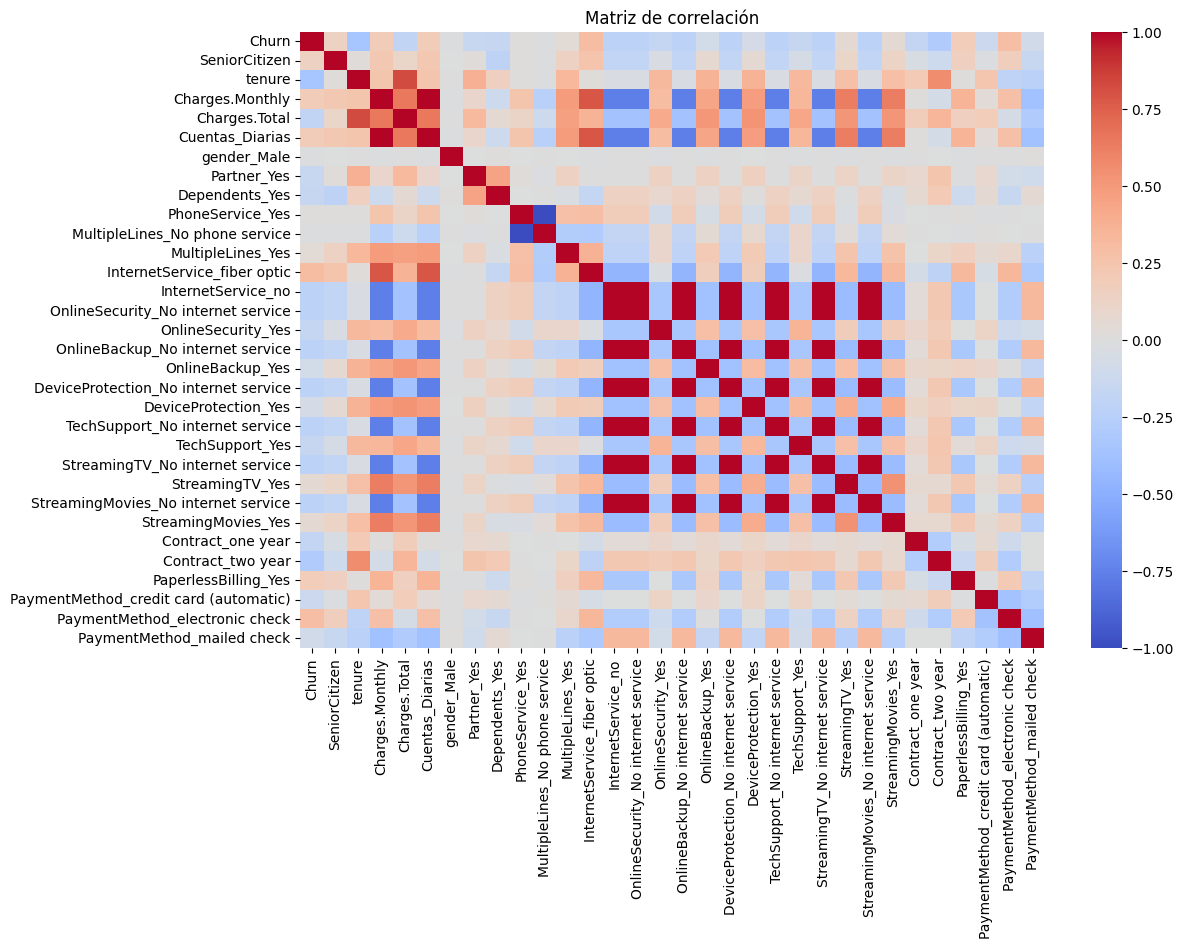

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

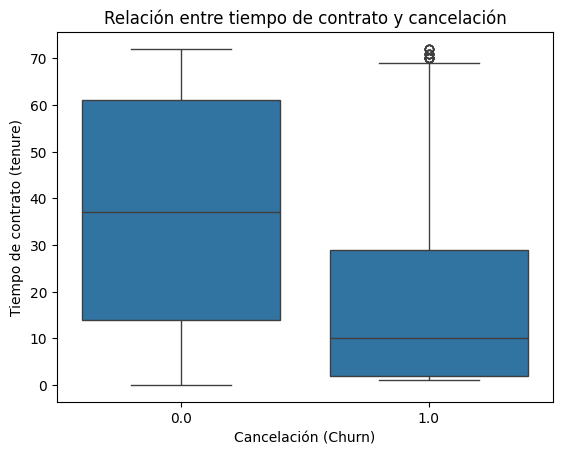

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Churn"], y=df["tenure"])
plt.title("Relación entre tiempo de contrato y cancelación")
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Tiempo de contrato (tenure)")
plt.show()

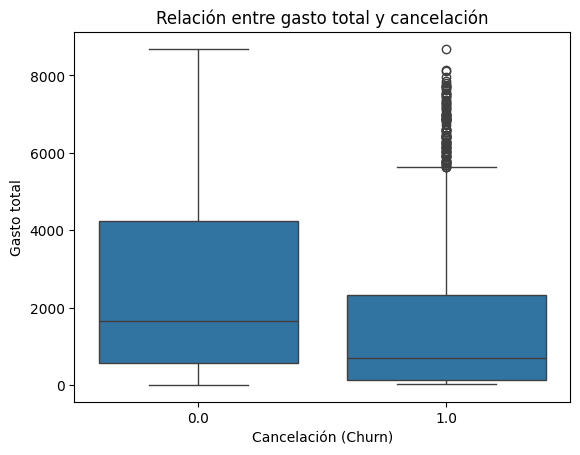

In [12]:
sns.boxplot(x=df["Churn"], y=df["Charges.Total"])
plt.title("Relación entre gasto total y cancelación")
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Gasto total")
plt.show()

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=1000)
modelo_logistico.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [16]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
y_pred_logistico = modelo_logistico.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_logistico))
print("Precision:", precision_score(y_test, y_pred_logistico))
print("Recall:", recall_score(y_test, y_pred_logistico))
print("F1-score:", f1_score(y_test, y_pred_logistico))

Accuracy: 0.8124713434204494
Precision: 0.6357615894039735
Recall: 0.5413533834586466
F1-score: 0.584771573604061


In [19]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_logistico)

array([[1484,  165],
       [ 244,  288]])

In [20]:
y_pred_rf = modelo_rf.predict(X_test)

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.8000917010545622
Precision: 0.6085972850678733
Recall: 0.5056390977443609
F1-score: 0.5523613963039015


In [22]:
confusion_matrix(y_test, y_pred_rf)

array([[1476,  173],
       [ 263,  269]])

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistico))

              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88      1649
         1.0       0.64      0.54      0.58       532

    accuracy                           0.81      2181
   macro avg       0.75      0.72      0.73      2181
weighted avg       0.80      0.81      0.81      2181



In [24]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.85      0.90      0.87      1649
         1.0       0.61      0.51      0.55       532

    accuracy                           0.80      2181
   macro avg       0.73      0.70      0.71      2181
weighted avg       0.79      0.80      0.79      2181



In [25]:
import pandas as pd

importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias.sort_values(ascending=False).head(10)

,0
Charges.Total,0.169695
tenure,0.155499
Cuentas_Diarias,0.129012
Charges.Monthly,0.128742
Contract_two year,0.035117
InternetService_fiber optic,0.032455
PaymentMethod_electronic check,0.030939
gender_Male,0.025819
PaperlessBilling_Yes,0.023451
OnlineSecurity_Yes,0.022521


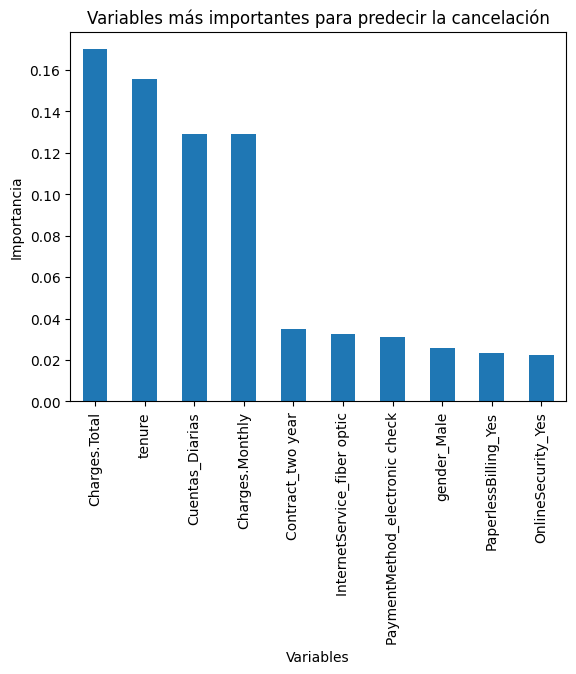

In [26]:
importancias.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Variables más importantes para predecir la cancelación")
plt.ylabel("Importancia")
plt.xlabel("Variables")
plt.show()

In [27]:
coeficientes = pd.Series(modelo_logistico.coef_[0], index=X.columns)
coeficientes.sort_values(ascending=False).head(10)

,0
InternetService_fiber optic,0.544673
PaperlessBilling_Yes,0.358222
PaymentMethod_electronic check,0.245287
SeniorCitizen,0.236666
MultipleLines_No phone service,0.233854
StreamingMovies_Yes,0.194267
MultipleLines_Yes,0.134044
StreamingTV_Yes,0.086824
Charges.Monthly,0.003951
Charges.Total,0.000380


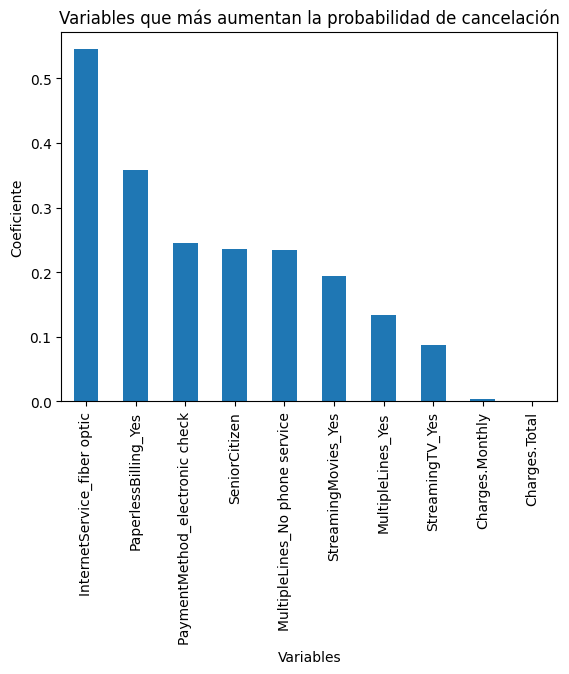

In [28]:
coeficientes.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Variables que más aumentan la probabilidad de cancelación")
plt.ylabel("Coeficiente")
plt.xlabel("Variables")
plt.show()

## Informe de Modelado y Factores de Cancelación

En esta etapa del proyecto desarrollé modelos de clasificación para predecir la cancelación de clientes en Telecom X. El objetivo fue no solo comparar el desempeño de distintos modelos, sino también identificar qué variables tienen mayor influencia en la evasión de clientes.

Para ello, entrené una Regresión Logística y un Random Forest, y evalué su rendimiento con métricas como accuracy, precision, recall, F1-score y matriz de confusión. Además, analicé la importancia de las variables y los coeficientes de los modelos para entender qué factores están más asociados con la cancelación.

In [29]:
importancias.sort_values(ascending=False).head(10)

,0
Charges.Total,0.169695
tenure,0.155499
Cuentas_Diarias,0.129012
Charges.Monthly,0.128742
Contract_two year,0.035117
InternetService_fiber optic,0.032455
PaymentMethod_electronic check,0.030939
gender_Male,0.025819
PaperlessBilling_Yes,0.023451
OnlineSecurity_Yes,0.022521


In [30]:
coeficientes.sort_values(ascending=False).head(10)

,0
InternetService_fiber optic,0.544673
PaperlessBilling_Yes,0.358222
PaymentMethod_electronic check,0.245287
SeniorCitizen,0.236666
MultipleLines_No phone service,0.233854
StreamingMovies_Yes,0.194267
MultipleLines_Yes,0.134044
StreamingTV_Yes,0.086824
Charges.Monthly,0.003951
Charges.Total,0.000380


## Factores que influyen en la cancelación de clientes

A partir del análisis de los modelos desarrollados, fue posible identificar las variables que tienen mayor influencia en la cancelación de clientes en Telecom X.

Según el modelo Random Forest, algunas de las variables más importantes fueron el gasto total del cliente (Charges.Total), el tiempo de permanencia en la empresa (tenure), el gasto diario estimado (Cuentas_Diarias) y el gasto mensual (Charges.Monthly). Esto sugiere que el comportamiento de gasto y la duración de la relación con la empresa son factores clave en la probabilidad de cancelación.

Por otro lado, el modelo de Regresión Logística mostró que variables relacionadas con el tipo de servicio y el método de pago también tienen un impacto importante. Entre ellas destacan InternetService_fiber optic, PaperlessBilling_Yes y PaymentMethod_electronic check. Esto indica que ciertos tipos de servicios de internet y métodos de pago pueden estar asociados con una mayor probabilidad de cancelación.

Además, variables como SeniorCitizen y algunos servicios adicionales como streaming o múltiples líneas también presentan cierta influencia en la predicción del churn.

En general, los resultados muestran que tanto el comportamiento de gasto como las características del servicio contratado influyen en la decisión de los clientes de cancelar sus servicios.

## Recomendaciones estratégicas para reducir la cancelación

Con base en los resultados obtenidos en los modelos predictivos, es posible proponer algunas estrategias que podrían ayudar a Telecom X a reducir la cancelación de clientes.

En primer lugar, el tiempo de permanencia del cliente en la empresa mostró una relación importante con la cancelación. Esto sugiere que los clientes más nuevos presentan un mayor riesgo de cancelar el servicio. Por esta razón, sería recomendable implementar programas de fidelización durante los primeros meses de servicio, ofreciendo incentivos o beneficios que fortalezcan la relación con el cliente.

También se observó que variables relacionadas con el gasto mensual y el gasto total tienen un impacto en la cancelación. Esto indica que el valor percibido del servicio puede influir en la decisión de los clientes. En este sentido, la empresa podría evaluar estrategias de ajuste de precios, paquetes personalizados o promociones que aumenten la percepción de valor.

Además, algunos factores relacionados con el tipo de servicio, como el uso de internet por fibra óptica o ciertos métodos de pago, mostraron influencia en los modelos. Esto sugiere que sería útil analizar más profundamente la experiencia del cliente en estos segmentos para identificar posibles problemas de satisfacción o calidad del servicio.

En conclusión, la combinación de análisis de datos y modelos predictivos permite identificar perfiles de clientes con mayor riesgo de cancelación. Esta información puede ayudar a Telecom X a anticiparse al problema y diseñar estrategias de retención más efectivas.